# 🌍 COVID-19 Global Data Analysis

This project analyzes global COVID-19 data to understand how the pandemic evolved across different countries and regions.

The analysis focuses on:

• Confirmed cases  
• Deaths  
• Recovered cases  
• Active cases  
• Time trends  
• Country comparisons  

Using data analysis, visualization, and statistical testing, we aim to extract meaningful insights from the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [2]:
# read the dataset
df = pd.read_csv("covid_19.csv")
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


### Observation

The dataset contains COVID-19 records for multiple countries across different dates.  
It includes information about confirmed cases, deaths, recoveries, and active cases.

# Data Understandin 

In [3]:
df.shape

(49068, 10)

In [4]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [6]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

### Observation

The dataset contains thousands of records with numerical columns such as Confirmed, Deaths, Recovered, and Active.

The Date column represents the timeline of the pandemic across countries.

# Data Cleaning 


In [7]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

### Observation

The column **Province/State** contains many missing values.  
Since most records are at the country level, these missing values are acceptable.

In [8]:
# convert data column
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.date

### Observation

The Date column has been converted to datetime format, which allows us to analyze trends over time.

# Checking Duplicates 

In [9]:
df.duplicated().sum()

0

### Observation

No duplicate records were found in the dataset.

# 📊 6. Exploratory Data Analysis (EDA)

In [10]:
top_cases = df.groupby("Country/Region")["Confirmed"].max().sort_values(ascending=False).head(10)

top_cases

Country/Region
US                4290259
Brazil            2442375
India             1480073
Russia             816680
South Africa       452529
Mexico             395489
Peru               389717
Chile              347923
United Kingdom     300111
Iran               293606
Name: Confirmed, dtype: int64

### Top 10 Countries by Confirmed Cases

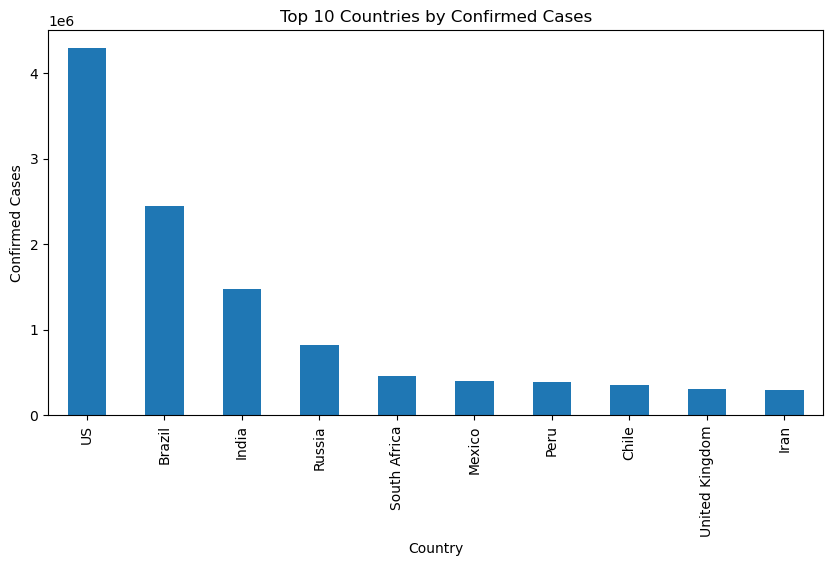

In [11]:
top_cases.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Countries by Confirmed Cases")
plt.ylabel("Confirmed Cases")
plt.xlabel("Country")

plt.show()

### Observation

Some countries recorded significantly higher COVID-19 cases compared to others.  
These countries were the major hotspots during the pandemic.

### Top Countries By Death

In [12]:
top_deaths = df.groupby("Country/Region")["Deaths"].max().sort_values(ascending=False).head(10)

top_deaths

Country/Region
US                148011
Brazil             87618
United Kingdom     45759
Mexico             44022
Italy              35112
India              33408
France             30096
Spain              28752
Peru               18418
Iran               15912
Name: Deaths, dtype: int64

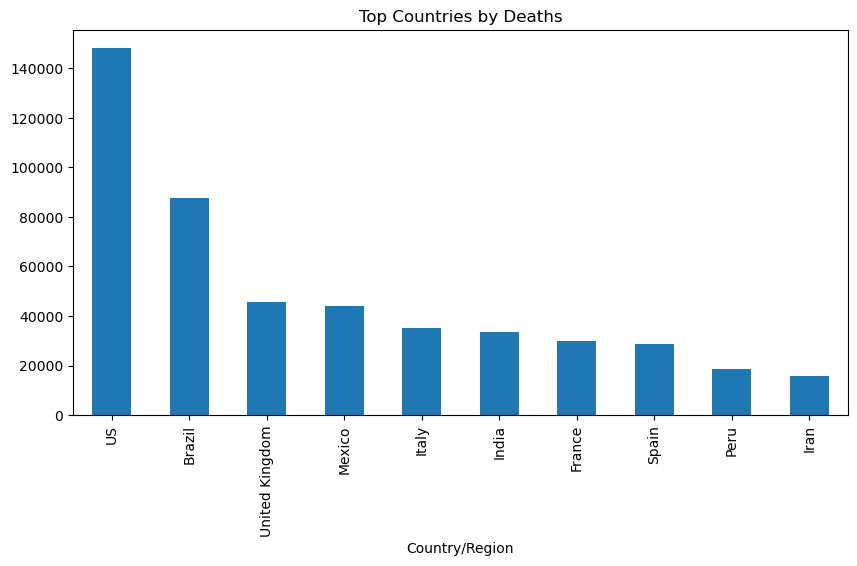

In [13]:
top_deaths.plot(kind='bar', figsize=(10,5))

plt.title("Top Countries by Deaths")

plt.show()

### Observation

Countries with higher confirmed cases also tend to have higher deaths, showing a strong relationship between infection spread and mortality.

### Global Cases Over Time 

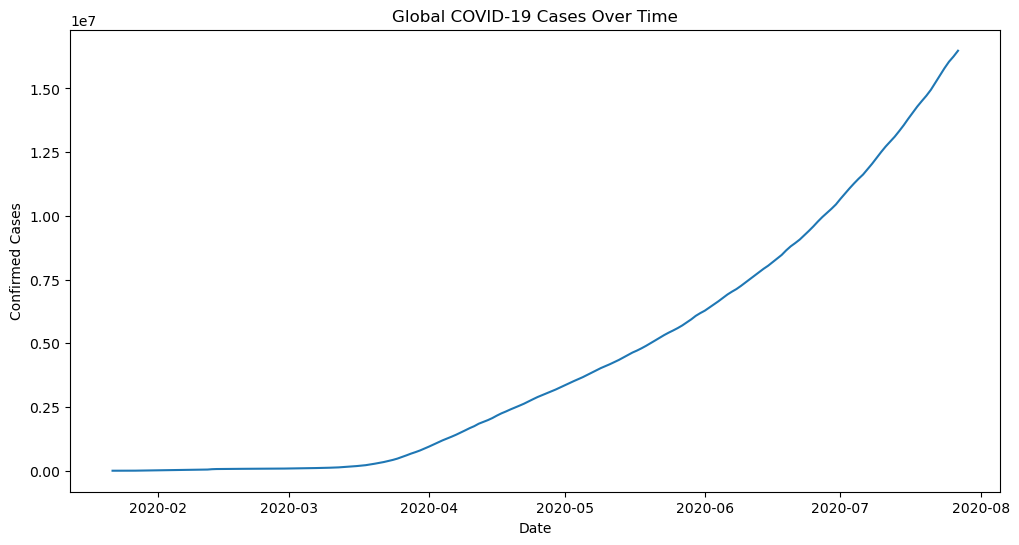

In [14]:
daily_cases = df.groupby("Date")["Confirmed"].sum()

plt.figure(figsize=(12,6))

plt.plot(daily_cases)

plt.title("Global COVID-19 Cases Over Time")

plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.show()

### Observation

The line chart shows a strong upward trend in confirmed cases over time, reflecting the global spread of COVID-19.

### Distribution Of Cases 

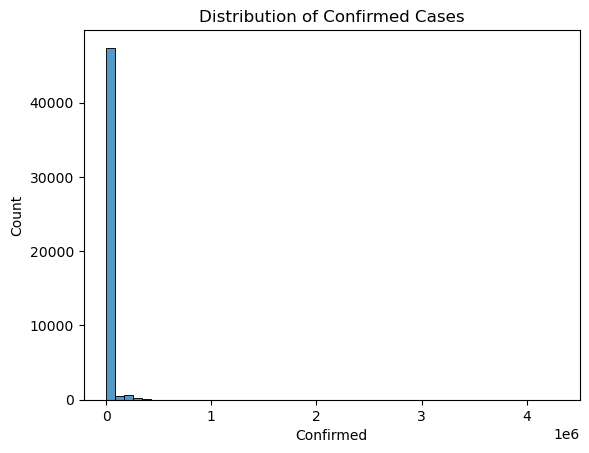

In [15]:
sns.histplot(df["Confirmed"], bins=50)

plt.title("Distribution of Confirmed Cases")

plt.show()

### Observation

The distribution shows that most countries have relatively lower case numbers, while a few countries have extremely high cases.

## Analytic Question 

1. Which country recorded the highest confirmed cases?
2. Which country has the highest deaths?
3. Which country has the highest recovered cases?
4. Which country has the highest active cases?
5. How did global confirmed cases change over time?
6. Which WHO region recorded the highest cases?
7. Which WHO region recorded the highest deaths?
8. What is the relationship between confirmed cases and deaths?
9. Which countries managed to recover the most patients?
10. How are active cases distributed across countries?
11. Which regions were most affected by COVID-19?
12. Are deaths increasing proportionally with confirmed cases?
13. What is the recovery trend across countries?
14. Which countries have the lowest number of deaths?
15. Is there a correlation between confirmed and recovered cases?

# Statistical Test

In [16]:
df[['Confirmed','Deaths','Recovered','Active']].corr()

,Confirmed,Deaths,Recovered,Active
Confirmed,1.000000,0.912361,0.895506,0.950255
Deaths,0.912361,1.000000,0.763090,0.891858
Recovered,0.895506,0.763090,1.000000,0.713088
Active,0.950255,0.891858,0.713088,1.000000


### Observation

There is a strong positive correlation between confirmed cases and deaths.  
This indicates that countries with more infections generally experienced higher death counts.

### Person Correlation Test

In [17]:
stats.pearsonr(df['Confirmed'], df['Deaths'])

PearsonRResult(statistic=0.9123609953778936, pvalue=0.0)

### Observation

The Pearson correlation test shows a strong positive relationship between confirmed cases and deaths, meaning both variables increase together.

# T-Test

In [18]:
region1 = df[df['WHO Region']=="Europe"]['Deaths']
region2 = df[df['WHO Region']=="Africa"]['Deaths']

stats.ttest_ind(region1, region2)

TtestResult(statistic=21.83157973760823, pvalue=1.206788837759618e-104, df=24062.0)

### Observation

The t-test compares death rates between Europe and Africa.  
The result indicates whether the difference between the two regions is statistically significant.

# ANOVA Test

In [19]:
stats.f_oneway(
df[df['WHO Region']=="Europe"]['Confirmed'],
df[df['WHO Region']=="Africa"]['Confirmed'],
df[df['WHO Region']=="Americas"]['Confirmed']
)

F_onewayResult(statistic=199.39963570729404, pvalue=8.423711635007067e-87)

### Observation

ANOVA compares confirmed cases across multiple regions to determine whether their averages differ significantly.

# Regression Analytics

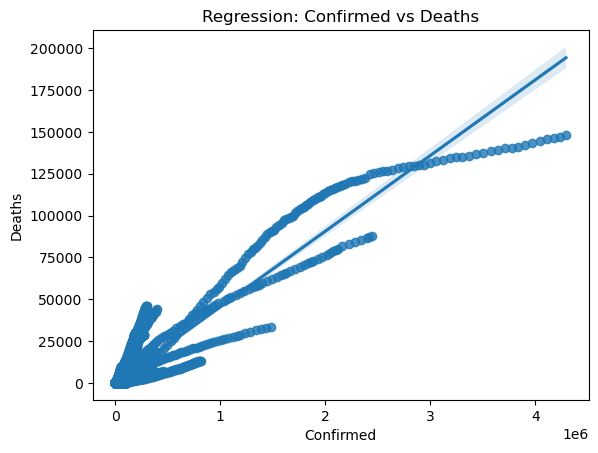

In [20]:
sns.regplot(x="Confirmed", y="Deaths", data=df)

plt.title("Regression: Confirmed vs Deaths")

plt.show()

### Observation

The regression plot shows a clear positive relationship between confirmed cases and deaths, suggesting that higher infections lead to increased mortality.

# Key Insight

• Countries with higher confirmed cases also show higher deaths.

• The pandemic spread rapidly over time across the globe.

• Certain regions were more heavily affected than others.

• Recovery numbers increased along with confirmed cases.

• Statistical analysis confirms strong relationships between cases, deaths, and recoveries.

# Conclusion 

This project analyzed global COVID-19 data to understand the spread and impact of the pandemic.

Through data cleaning, exploratory data analysis, visualization, and statistical testing, we discovered important patterns such as strong relationships between confirmed cases and deaths and regional differences in pandemic impact.

These insights demonstrate how data analysis can help understand large-scale global health crises.